In [1]:
import time
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

import numpy as np
import pandas as pd
import os

from pathlib import Path

In [2]:
import scanpy as sc
import omicverse as ov
import matplotlib.pyplot as plt
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.7, Tutorials: https://omicverse.readthedocs.io/
All dependencies are satisfied.


In [3]:
data_dir = Path("/workspace/pyfaster/examples/gene/data")

In [4]:
input_file = data_dir / "valid_gene_20115.csv"

with open(input_file, "r") as f:
    gene_df = pd.read_csv(f, index_col=0)

In [5]:
gene_df.shape

(20115, 308)

In [6]:
gene_df.head()

,TCGA-EA-A3HT-01,TCGA-FU-A3HZ-01,TCGA-FU-A3TQ-01,TCGA-DS-A0VK-01,TCGA-UC-A7PG-01,TCGA-C5-A7UE-01,TCGA-C5-A1MJ-01,TCGA-UC-A7PI-01,TCGA-C5-A1MF-01,TCGA-EA-A5ZF-01,...,TCGA-JW-A5VI-01,TCGA-VS-A9UD-01,TCGA-C5-A1BQ-01,TCGA-MU-A8JM-01,TCGA-DS-A0VM-01,TCGA-MY-A5BF-01,TCGA-EA-A556-01,TCGA-IR-A3LA-01,TCGA-VS-AA62-01,TCGA-ZJ-AAXB-01
sample,,,,,,,,,,,,,,,,,,,,,
ARHGEF10L,10.5288,8.9938,11.1427,9.6531,10.7841,9.1479,9.9180,11.3020,9.7611,9.1857,...,9.7557,9.4056,9.4501,8.8562,9.3147,9.6083,8.6916,9.7172,8.5571,9.3718
HIF3A,2.3360,3.0519,2.8401,4.7910,5.0874,1.0768,5.0908,4.0824,6.6607,7.5791,...,2.5435,3.4127,3.4331,1.4381,2.3607,1.5007,9.9533,3.3598,2.4615,5.6179
RNF17,1.1089,0.0000,2.3787,2.8581,0.5638,0.0000,0.0000,0.0000,1.9885,0.8653,...,0.0000,1.4617,0.4078,2.2769,1.7500,0.9373,0.0000,0.0000,0.5858,0.0000
RNF10,11.5901,11.7196,11.7059,11.6354,11.9265,11.5634,11.7036,11.5815,11.5778,11.3493,...,11.3065,11.5076,11.8264,12.0696,11.5247,11.7102,11.9712,11.5545,11.7368,12.0085
RNF11,11.5206,10.8445,12.4498,11.1440,11.4774,11.3357,10.2908,10.0199,9.6877,10.8719,...,11.4717,10.3800,11.2518,11.5606,9.9498,11.9397,11.0097,10.9808,10.5334,10.8950


In [7]:
from statsmodels import robust #import package
gene_mad=gene_df.apply(robust.mad) #use function to calculate MAD
gene_df=gene_df.T
gene_df=gene_df.loc[gene_mad.sort_values(ascending=False).index[:2000]]


In [8]:
gene_df.head()

sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
TCGA-EK-A3GJ-01,9.1567,0.0000,0.4062,11.5965,10.8002,9.8379,11.9067,0.7228,0.0,0.9823,...,0.0,0.0000,4.9952,2.6330,9.1518,12.3216,4.0540,11.5769,1.5613,10.6715
TCGA-EA-A5O9-01,9.5993,1.9285,0.4865,11.6676,10.8604,10.2710,12.3669,1.9285,0.0,1.3806,...,0.0,0.4865,4.4228,0.0000,8.9524,11.3738,6.8539,10.9754,1.9285,10.4320
TCGA-C5-A7UC-01,8.6086,1.3908,0.8569,11.5274,10.6270,9.6216,12.3177,2.5525,0.0,2.2172,...,0.0,0.0000,2.0856,0.4912,9.0216,13.9373,4.8772,11.7365,1.9407,10.5322
TCGA-VS-A953-01,8.1433,1.0167,0.0000,11.5579,10.7936,10.1710,12.1584,1.6072,0.0,3.6550,...,0.0,0.0000,3.2521,2.1411,8.8786,12.4207,4.9707,11.1842,1.7603,9.5436
TCGA-GH-A9DA-01,9.6675,0.0000,0.5025,12.0872,10.3475,10.3626,11.9478,2.1156,0.0,3.7551,...,0.0,0.0000,3.8415,1.4152,9.1586,14.5180,4.5801,10.8692,4.4759,11.4817


In [9]:
#import PyWGCNA
pyWGCNA_5xFAD = ov.bulk.pyWGCNA(name='5xFAD_2k', 
                              species='mus musculus', 
                              geneExp=gene_df, 
                              outputPath='',
                              save=True)
pyWGCNA_5xFAD.geneExpr.to_df().head(5)

Saving data to be True, checking requirements ...


sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
TCGA-EK-A3GJ-01,9.1567,0.0000,0.4062,11.5965,10.8002,9.8379,11.9067,0.7228,0.0,0.9823,...,0.0,0.0000,4.9952,2.6330,9.1518,12.3216,4.0540,11.5769,1.5613,10.6715
TCGA-EA-A5O9-01,9.5993,1.9285,0.4865,11.6676,10.8604,10.2710,12.3669,1.9285,0.0,1.3806,...,0.0,0.4865,4.4228,0.0000,8.9524,11.3738,6.8539,10.9754,1.9285,10.4320
TCGA-C5-A7UC-01,8.6086,1.3908,0.8569,11.5274,10.6270,9.6216,12.3177,2.5525,0.0,2.2172,...,0.0,0.0000,2.0856,0.4912,9.0216,13.9373,4.8772,11.7365,1.9407,10.5322
TCGA-VS-A953-01,8.1433,1.0167,0.0000,11.5579,10.7936,10.1710,12.1584,1.6072,0.0,3.6550,...,0.0,0.0000,3.2521,2.1411,8.8786,12.4207,4.9707,11.1842,1.7603,9.5436
TCGA-GH-A9DA-01,9.6675,0.0000,0.5025,12.0872,10.3475,10.3626,11.9478,2.1156,0.0,3.7551,...,0.0,0.0000,3.8415,1.4152,9.1586,14.5180,4.5801,10.8692,4.4759,11.4817


Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..



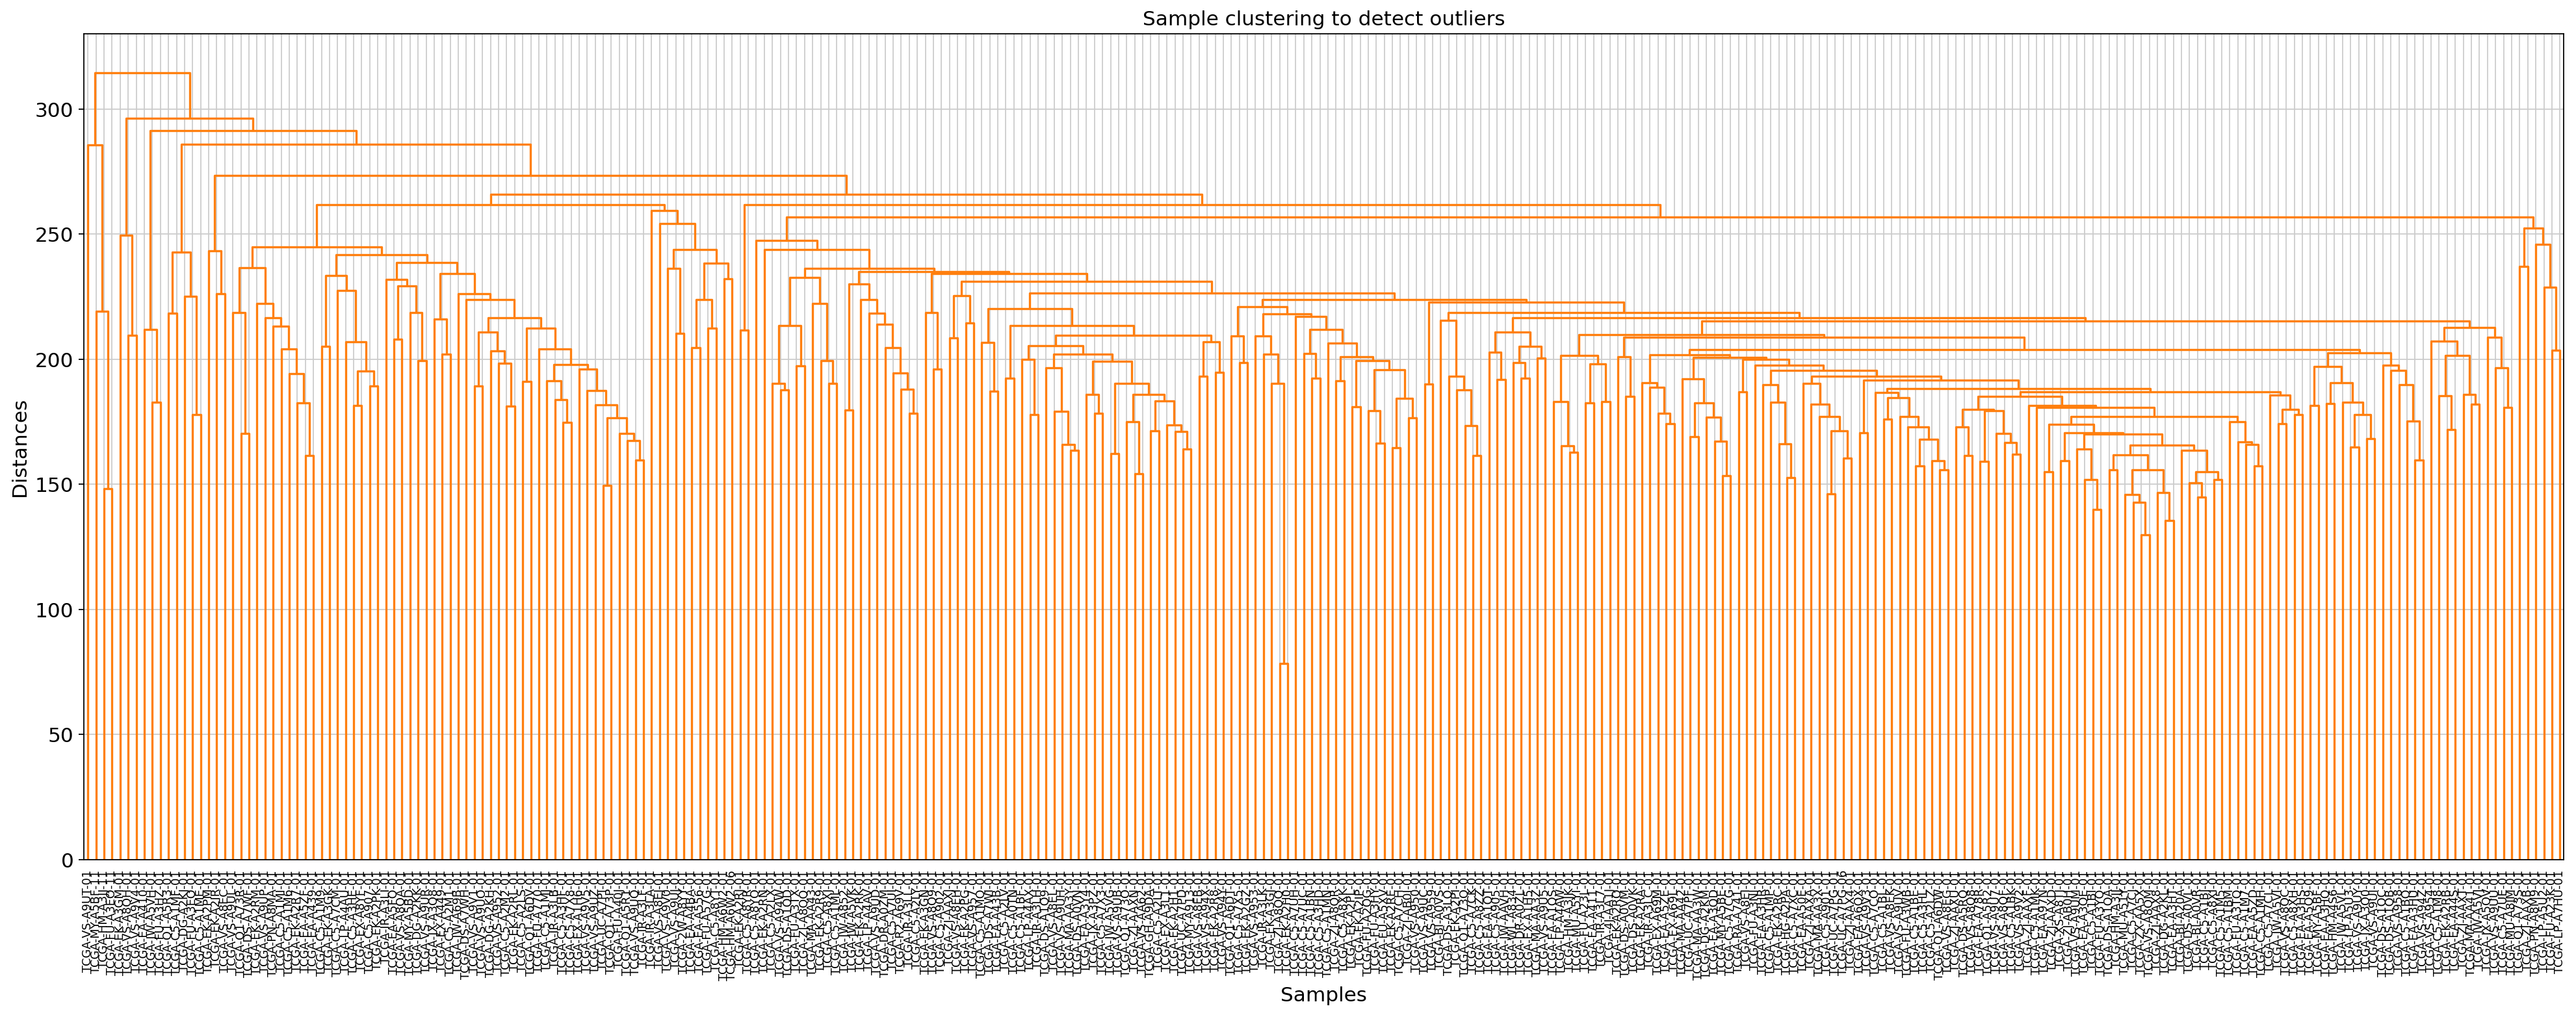

In [10]:
pyWGCNA_5xFAD.preprocess()

Run pyWGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  2267
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.009588 -0.265306       0.950024  1239.703545  1210.581032   
1       2  0.563105 -1.895001       0.991436   258.241594   232.024541   
2       3  0.793036 -2.417659       0.995537    74.982976    56.594467   
3       4  0.860648 -2.336339       0.985092    27.494742    16.365902   
4       5   0.93895 -2.020038       0.991742     12.00492     5.458609   
5       6  0.959655 -1.905879       0.992183     5.995853     2.067079   
6       7  0.960884 -1.821138       0.986743     3.326361     0.855355   
7       8  0.966267 -1.730661       0.989813      2.00476     0.377087   
8       9  0.965374 -1.665502       0.986781     1.290373     0.177308   
9      10  0.969585 -1.604669       0.990399      0.87539     0.086783   
10     11  0.971349 -1.556416       0.990102     0.619573     0.044604   
11     

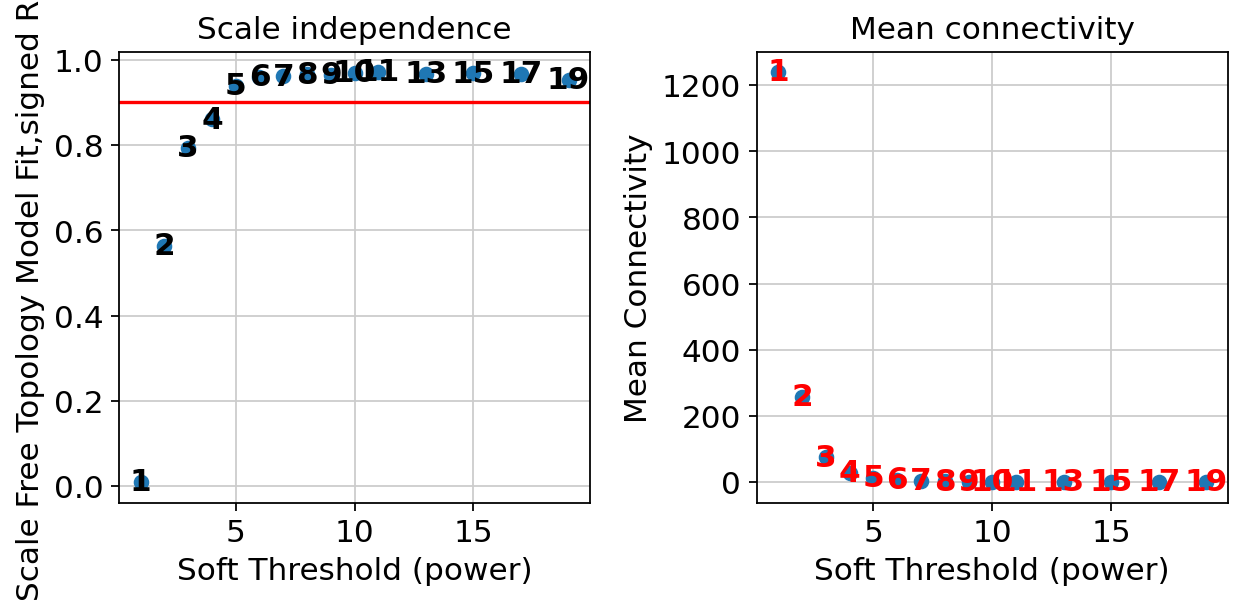

In [11]:
pyWGCNA_5xFAD.calculate_soft_threshold()

In [12]:
pyWGCNA_5xFAD.calculating_adjacency_matrix()

calculating adjacency matrix ...
	Done..



In [13]:
pyWGCNA_5xFAD.calculating_TOM_similarity_matrix()

calculating TOM similarity matrix ...
	Done..



Going through the merge tree...
..cutHeight not given, setting it to 0.9985667427382023  ===>  99% of the (truncated) height range in dendro.
..done.
Calculating 51 module eigengenes in given set...
	Done..

mergeCloseModules: Merging modules whose distance is less than 0.2
fixDataStructure: data is not a Dictionary: converting it into one.
multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 51 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 48 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 47 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 45 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calculating 43 module eigengenes in given set...
	Done..

multiSetMEs: Calculating module MEs.
  Working on set 1 ...
Calcula

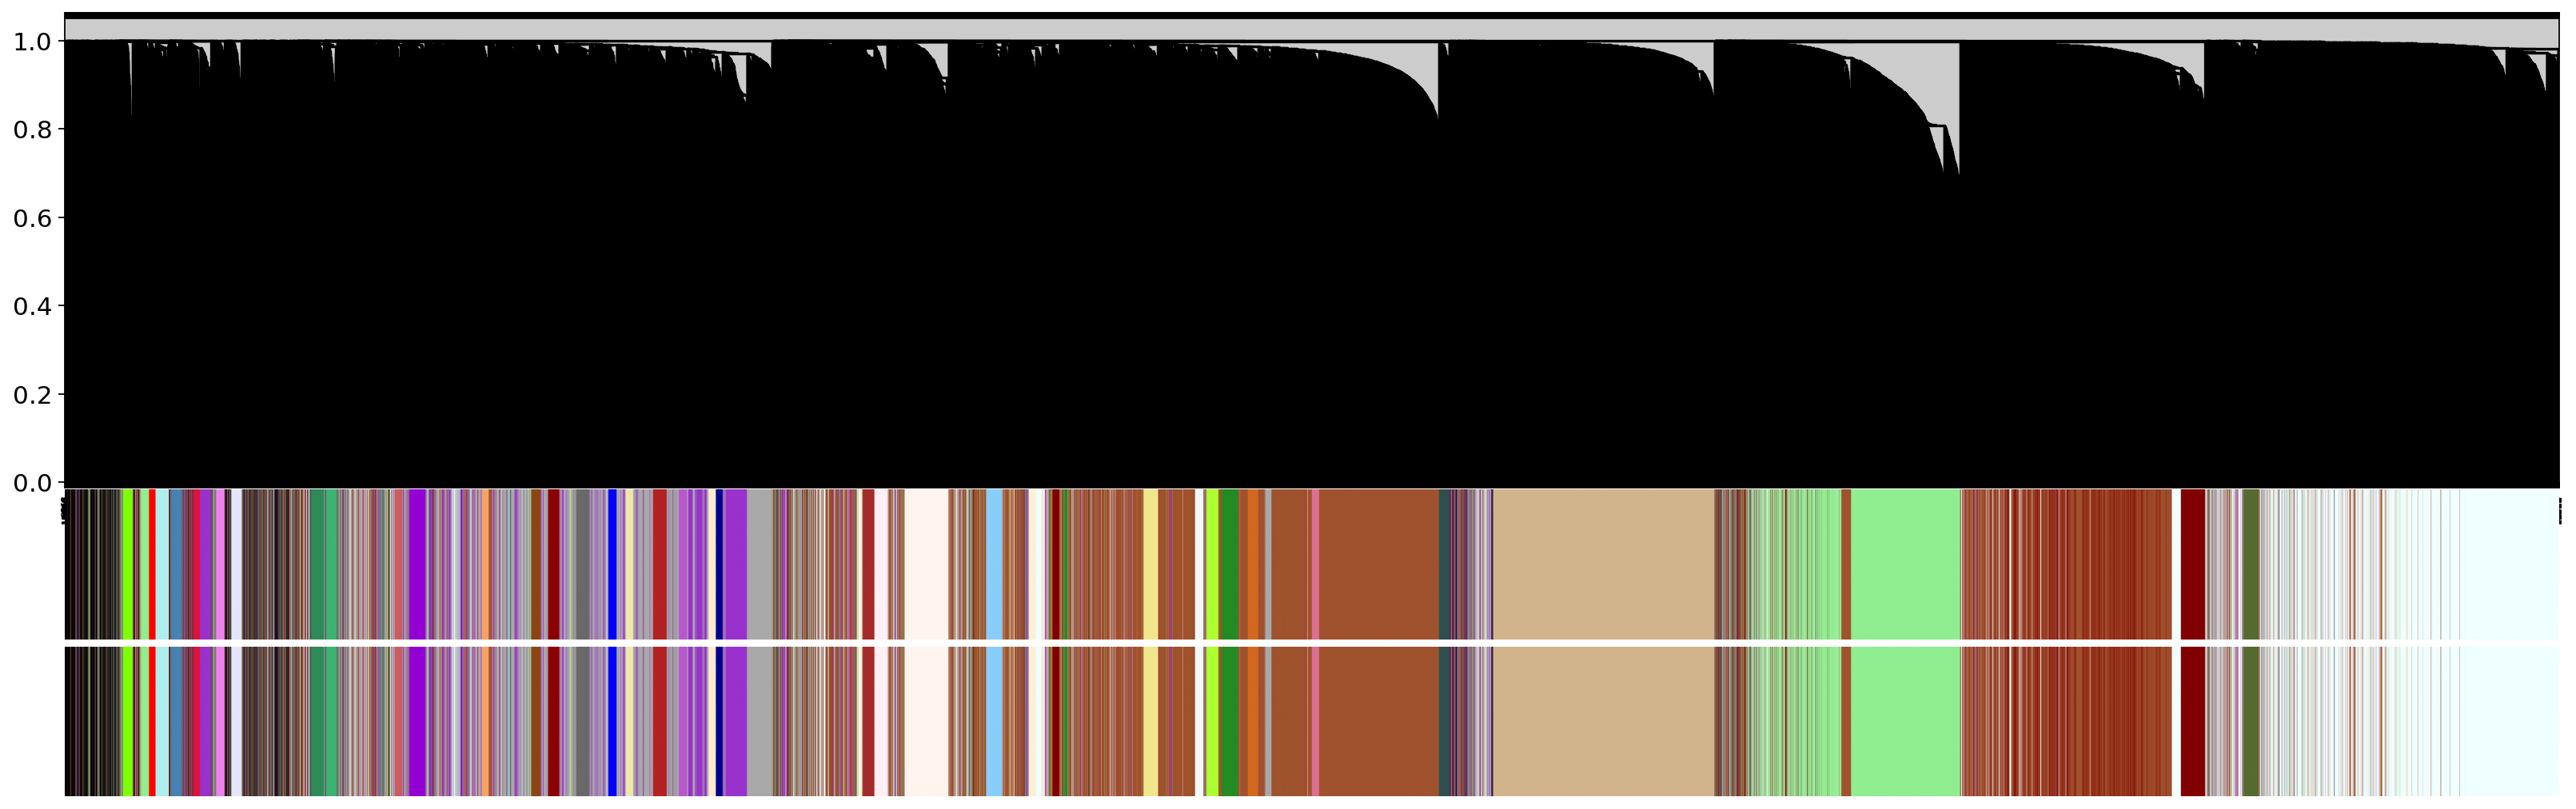

In [14]:
pyWGCNA_5xFAD.calculate_geneTree()
pyWGCNA_5xFAD.calculate_dynamicMods(kwargs_function={'cutreeHybrid': {'deepSplit': 2, 'pamRespectsDendro': False}})
pyWGCNA_5xFAD.calculate_gene_module(kwargs_function={'moduleEigengenes': {'softPower': 5}})

In [ ]:
pyWGCNA_5xFAD.plot_matrix(save=True)

In [ ]:
!say Debug 运行结束 9